In [2]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

experiment_analyses_dir = r"C:\Users\singel\Desktop\URP 2025\driving_exp_1_analyses\experiment_analyses"
# r"C:\Users\graci\Dropbox\PAndA\Thesis Experiment 1\scripts\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/singel/Dropbox/data (1)/main_data"
# "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)
print('Success!')

def getCostMatrix(dist_mat):
    """
    Find minimum-cost path through matrix `dist_mat` using dynamic programming.

    The cost of a path is defined as the sum of the matrix entries on that
    path. See the following for details of the algorithm:

    - http://en.wikipedia.org/wiki/Dynamic_time_warping
    - https://www.ee.columbia.edu/~dpwe/resources/matlab/dtw/dp.m

    The notation in the first reference was followed, while Dan Ellis's code
    (second reference) was used to check for correctness. Returns a list of
    path indices and the cost matrix.
    """

    N, M = dist_mat.shape # Matrix of nxm shape

    # Initialize the cost matrix with first entry zero and infinity entries along edges -> |__
    cost_mat = np.zeros((N + 1, M + 1))
    for i in range(1, N + 1):
        cost_mat[i, 0] = np.inf
    for i in range(1, M + 1):
        cost_mat[0, i] = np.inf

    # Fill the cost matrix while keeping traceback information
    traceback_mat = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            penalty = [
                cost_mat[i, j],      # match (0)
                cost_mat[i, j + 1],  # insertion (1)
                cost_mat[i + 1, j]]  # deletion (2)
            i_penalty = np.argmin(penalty)
            cost_mat[i + 1, j + 1] = dist_mat[i, j] + penalty[i_penalty]
            traceback_mat[i, j] = i_penalty

    # Traceback from last entry back to first to get alignment path
    i = N - 1
    j = M - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        tb_type = traceback_mat[i, j]
        if tb_type == 0:
            # Match
            i = i - 1
            j = j - 1
        elif tb_type == 1:
            # Insertion
            i = i - 1
        elif tb_type == 2:
            # Deletion
            j = j - 1
        path.append((i, j))

    # Strip infinity edges from cost_mat before returning
    cost_mat = cost_mat[1:, 1:]
    return (path[::-1], cost_mat) # Return path and cost_mat

Success!


In [3]:
# Useful references -------------------------
familiar_group_ids = ["baggy", "bash", "boned", "cargo","five", "grip", "mule", "polio", "rerun", "slate", "slept", "trial", "yeast"] # wad was excluded because his csv files are fucked Dx
unfamiliar_group_ids = ["atom", "brim", "chef", "clerk", "debt", "grid", "lens", "limb", "most","slimy", "swarm", "wok"]
track_pieces = ['chicane','triple_s', 'symmetric_parabolic', 'traffic_circle', 'asymmetric_parabolic_2', 't_turn', 'asymmetric_parabolic_1', 'spiral'] # 8 track segments in T010 and T011 not including straight pieces

average_costs = []
### Start Interation ###
group_cost = 0
for group in [familiar_group_ids, unfamiliar_group_ids]:
    for subject_id in group:
        
        # Get objects associated to a given subject and their trial
        subject_object = subject_dict[subject_id]
        
        trial_object_ten = subject_object.trials[9]
        
        trial_object_eleven = subject_object.trials[10]
        
        # Retrieve useful information
        track_piece_object_dict_ten = trial_object_ten.pieces # dictionary that contains track_piece names and their associated track_piece_object 
        track_piece_object_dict_eleven = trial_object_eleven.pieces # dictionary that contains track_piece names and their associated track_piece_object instantiation

        # print(f" Map for Trial {trial_number}:","Map", trial_map_number,"\n","List of track pieces:","\n", track_piece_list) # high_visibility, then good. if low_visibility, that means the track piece has fog 
        
        subject_cost = 0
        for track_piece_id in track_pieces:
            # To get data associated to a given track piece! These are dataframes that are filtered for only the data associated to a given track piece
            track_piece_object_ten = track_piece_object_dict_ten[track_piece_id] # get the track piece object associated to the track 
            track_piece_object_eleven = track_piece_object_dict_eleven[track_piece_id] # get the track piece object associated to the track piece
    
            track_piece_trajectory_ten = track_piece_object_ten.trajectory_df # get the trajectory dataframe associated to track piece
            trajectory_ten = track_piece_trajectory_ten[['pos_x', 'pos_z']].values # trajectory dataframe to np array
            track_piece_trajectory_eleven = track_piece_object_eleven.trajectory_df
            trajectory_eleven = track_piece_trajectory_eleven[['pos_x', 'pos_z']].values
    
            dist_matrix = cdist(trajectory_ten, trajectory_eleven, 'euclidean') # distance matrix between the two trajectories
    
            # Gets cost matrix and DTW path that corresponds to distance matrix
            path, cost_matrix = getCostMatrix(dist_matrix)
    
            # Normalizes cost using matrix dimension sum method with the top right most entry in the matrix being the final cost value
            # which is divided by the product of the matrix dimensions
            norm_cost = cost_matrix[cost_matrix.shape[0] - 1][cost_matrix.shape[1] - 1] / (cost_matrix.shape[0] * cost_matrix.shape[1])
    
            # Sums subjects norm cost for overall cost once every piece norm_cost is calculated
            subject_cost += norm_cost
            print(f'{subject_id}: {subject_cost}')
            
        # Sums average cost of each subject for overall group cost
        group_cost += subject_cost/len(track_pieces)
        
    # Appends average cost of group to average_costs in the order of familiar and unfamiliar
    average_costs.append(group_cost/len(group))

print(average_costs)

baggy: 0.00407353918649008
baggy: 0.01070156008557284
baggy: 0.01557287305543255
baggy: 0.022037697097561777
baggy: 0.03811667887243562
baggy: 0.06198382983133846
baggy: 0.0698793403558954
baggy: 0.08508829963042865
bash: 0.004081455542385159
bash: 0.13538684123457242
bash: 0.16018278841216566
bash: 0.16958624719828055
bash: 0.19028435408730004
bash: 0.19393694303754655
bash: 0.3206180884153034
bash: 0.33202313177751996
boned: 0.003603760957338496
boned: 0.029340875718860918
boned: 0.03921116150622559
boned: 0.17568666107209494
boned: 0.2028793710810745
boned: 0.209803810951224
boned: 0.2251536010910949
boned: 0.23411819565227368
cargo: 0.020462396616889422
cargo: 0.0770730252601857
cargo: 0.10808591965390879
cargo: 0.2836795508849319
cargo: 0.33607982257762326
cargo: 0.3768759596743998
cargo: 0.4197226643224569
cargo: 0.5954884818559377
five: 0.0014758642861197185
five: 0.011668402431850617
five: 0.03266325567004891
five: 0.03828112620570914
five: 0.06602184696852287
five: 0.069031265

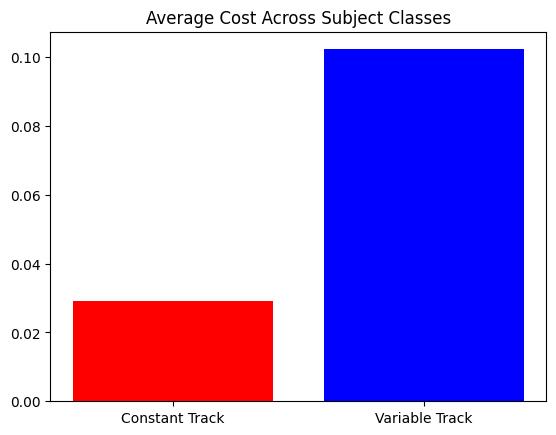

In [4]:
# Bar plot of average costs for each group
plt.bar(['Constant Track', 'Variable Track'], average_costs, color = ['red', 'blue'])
plt.title('Average Cost Across Subject Classes')
plt.show()

In [5]:
plt.savefig('Average Cost Across Subject Classes.png')

<Figure size 640x480 with 0 Axes>